# Quality Control and Filtering — GSE225275

**Dataset**: GSE225275 — Gastric antrum across 3 species (human, mouse, rat; 1 sample each)

**Workflow:**
1. Load raw count data (per-species h5ad files)
2. Process each species independently (different gene name conventions)
3. For each species: QC metrics → Stage 1 filtering → Stage 2 MAD filtering → Doublet detection
4. Save one filtered h5ad per species

**Input**: `GSE225275_human_raw.h5ad`, `GSE225275_mouse_raw.h5ad`, `GSE225275_rat_raw.h5ad`  
**Output**: `GSE225275_human_filtered.h5ad`, `GSE225275_mouse_filtered.h5ad`, `GSE225275_rat_filtered.h5ad`

**Note**: Cannot concatenate across species (different gene names). Each species has only 1 sample, so no within-species concatenation is needed either.

**Gene pattern notes:**
- Human: `MT-`, `^RP[SL]`, `^HB[^(P)]`
- Mouse: `mt-`, `^Rp[sl]`, `^Hb[^(p)]` — only 1 mito gene
- Rat: same patterns as mouse — 0 mito genes, 36 ribo, 3 hb

In [1]:
# =============================================================================
# CONFIGURATION
# =============================================================================

DATASET_ID = 'GSE225275'

INPUT_DIR = '../data/processed'
OUTPUT_DIR = '../data/processed'

# Species to process (each has 1 sample)
SPECIES_LIST = ['human', 'mouse', 'rat']

## 1. Load Raw Data

In [2]:
import os
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import median_abs_deviation
import scrublet as scr

sc.settings.set_figure_params(dpi=100, frameon=False, figsize=(6, 6), facecolor='white')
sc.settings.verbosity = 3

In [3]:
adatas_raw = {}

for species in SPECIES_LIST:
    file_path = f'{INPUT_DIR}/{DATASET_ID}_{species}_raw.h5ad'
    adata = sc.read_h5ad(file_path)
    adatas_raw[species] = adata
    region = adata.obs['region'].iloc[0]
    print(f"{species}: {adata.n_obs} cells x {adata.n_vars} genes | region={region}")

print(f"\nTotal cells across all species: {sum(a.n_obs for a in adatas_raw.values())}")

human: 3813 cells x 14330 genes | region=antrum


mouse: 4127 cells x 15107 genes | region=antrum


rat: 3722 cells x 15396 genes | region=antrum

Total cells across all species: 11662


## 2. Define QC Functions

All functions are defined here, then applied per-species in the processing loop below.

In [4]:
def calculate_qc_metrics(adata, species='mouse'):
    """Calculate QC metrics, adapting gene patterns to species."""
    if species == 'human':
        mito_pattern, ribo_pattern, hb_pattern = '^MT-', '^RP[SL]', '^HB[^(P)]'
    elif species in ('mouse', 'rat'):
        mito_pattern, ribo_pattern, hb_pattern = '^mt-', '^Rp[sl]', '^Hb[^(p)]'
    else:
        raise ValueError("Species must be 'human', 'mouse', or 'rat'")

    adata.var['mt'] = adata.var_names.str.match(mito_pattern)
    adata.var['ribo'] = adata.var_names.str.match(ribo_pattern)
    adata.var['hb'] = adata.var_names.str.match(hb_pattern)

    # Only include categories with genes present
    qc_vars = []
    for cat in ['mt', 'ribo', 'hb']:
        if adata.var[cat].sum() > 0:
            qc_vars.append(cat)
        else:
            print(f"  No {cat} genes found — skipping")

    sc.pp.calculate_qc_metrics(
        adata, qc_vars=qc_vars, percent_top=None, log1p=False, inplace=True
    )

    rename_map = {
        'pct_counts_mt': 'percent_mito',
        'pct_counts_ribo': 'percent_ribo',
        'pct_counts_hb': 'percent_hb'
    }
    adata.obs.rename(columns={k: v for k, v in rename_map.items() if k in adata.obs.columns}, inplace=True)

    print(f"  Mitochondrial genes: {adata.var['mt'].sum()}")
    print(f"  Ribosomal genes: {adata.var['ribo'].sum()}")
    print(f"  Hemoglobin genes: {adata.var['hb'].sum()}")

    return adata

In [5]:
def plot_qc_metrics(adata, title):
    """QC visualization adapted for available metrics."""
    has_mito = 'percent_mito' in adata.obs.columns and adata.obs['percent_mito'].sum() > 0

    metrics = ['n_genes_by_counts', 'total_counts']
    labels = ['Genes per cell', 'UMI counts']
    if has_mito:
        metrics.append('percent_mito')
        labels.append('% Mitochondrial')

    n_metrics = len(metrics)
    fig, axes = plt.subplots(2, n_metrics, figsize=(5 * n_metrics, 9))
    fig.suptitle(f'QC Metrics — {title}', fontsize=16)

    for i, (metric, label) in enumerate(zip(metrics, labels)):
        axes[0, i].hist(adata.obs[metric].values, bins=100, alpha=0.7, color='steelblue', edgecolor='white')
        axes[0, i].set_xlabel(label); axes[0, i].set_ylabel('Frequency')
        if metric == 'total_counts':
            axes[0, i].set_xscale('log')

        parts = axes[1, i].violinplot([adata.obs[metric].values], positions=[0], showmedians=True)
        for pc in parts['bodies']:
            pc.set_facecolor('steelblue'); pc.set_alpha(0.7)
        axes[1, i].set_ylabel(label); axes[1, i].set_xticks([])

    plt.tight_layout(); plt.show()

    # Scatter: genes vs UMIs
    fig, ax = plt.subplots(figsize=(6, 5))
    if has_mito:
        im = ax.scatter(adata.obs['total_counts'], adata.obs['n_genes_by_counts'],
                        c=adata.obs['percent_mito'], alpha=0.3, s=1, cmap='Reds')
        plt.colorbar(im, ax=ax, label='% Mito')
    else:
        ax.scatter(adata.obs['total_counts'], adata.obs['n_genes_by_counts'],
                   alpha=0.3, s=1, c='steelblue')
    ax.set_xlabel('Total UMI counts'); ax.set_ylabel('Number of genes')
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_title(f'{title} — Genes vs UMIs')
    plt.tight_layout(); plt.show()

    stat_cols = ['n_genes_by_counts', 'total_counts']
    if has_mito: stat_cols.append('percent_mito')
    print(f"\n{title} Summary:")
    print(adata.obs[stat_cols].agg(['count', 'mean', 'median', 'std', 'min', 'max']).round(2))

In [6]:
def find_knee_point(values, plot=False):
    """Find the knee point in a ranked curve using the maximum distance method."""
    sorted_values = np.sort(values)[::-1]
    log_values = np.log1p(sorted_values)
    log_rank = np.log1p(np.arange(len(sorted_values)))

    log_values_norm = (log_values - log_values.min()) / (log_values.max() - log_values.min() + 1e-10)
    log_rank_norm = (log_rank - log_rank.min()) / (log_rank.max() - log_rank.min() + 1e-10)

    x1, y1 = log_rank_norm[0], log_values_norm[0]
    x2, y2 = log_rank_norm[-1], log_values_norm[-1]

    distances = np.abs((y2-y1)*log_rank_norm - (x2-x1)*log_values_norm + x2*y1 - y2*x1) / \
                np.sqrt((y2-y1)**2 + (x2-x1)**2 + 1e-10)

    knee_idx = np.argmax(distances)
    return sorted_values[knee_idx]


def apply_stage1_filtering(adata, min_genes=200, min_counts=500, max_genes=None,
                           max_mito=20, max_hb=None, use_knee_point=False):
    """Stage 1: Basic cell filtering with fixed thresholds."""
    n_cells_before = adata.n_obs
    has_mito = 'percent_mito' in adata.obs.columns and adata.obs['percent_mito'].sum() > 0

    if use_knee_point:
        min_genes = max(find_knee_point(adata.obs['n_genes_by_counts'].values), 200)
        min_counts = max(find_knee_point(adata.obs['total_counts'].values), 500)

    print(f"Stage 1 Thresholds:")
    print(f"  Min genes: {min_genes}, Min UMIs: {min_counts}")
    if max_genes: print(f"  Max genes: {max_genes}")
    if has_mito and max_mito is not None:
        print(f"  Max mito %: {max_mito}%")
    else:
        print(f"  Max mito %: SKIPPED (0-1 mito genes)")
    if max_hb is not None: print(f"  Max HB %: {max_hb}%")

    # Apply filters
    sc.pp.filter_cells(adata, min_genes=min_genes)
    sc.pp.filter_cells(adata, min_counts=min_counts)
    if max_genes:
        sc.pp.filter_cells(adata, max_genes=max_genes)

    n_mito_filtered = 0
    if has_mito and max_mito is not None:
        n_before = adata.n_obs
        adata = adata[adata.obs['percent_mito'] < max_mito].copy()
        n_mito_filtered = n_before - adata.n_obs

    n_hb_filtered = 0
    if max_hb is not None and 'percent_hb' in adata.obs.columns:
        n_before = adata.n_obs
        adata = adata[adata.obs['percent_hb'] < max_hb].copy()
        n_hb_filtered = n_before - adata.n_obs

    n_removed = n_cells_before - adata.n_obs
    pct_removed = (n_removed / n_cells_before) * 100 if n_cells_before > 0 else 0

    print(f"\nStage 1 Results:")
    print(f"  Cells before: {n_cells_before}")
    print(f"  Cells after: {adata.n_obs}")
    print(f"  Removed: {n_removed} ({pct_removed:.1f}%)")
    if n_mito_filtered: print(f"    - High mito: {n_mito_filtered}")
    if n_hb_filtered: print(f"    - High HB: {n_hb_filtered}")

    return adata

In [7]:
def is_outlier(data, n_mads=3, direction='both'):
    """Detect outliers using MAD (Median Absolute Deviation)."""
    median = np.median(data)
    mad = median_abs_deviation(data)
    if direction == 'lower':
        return data < (median - n_mads * mad)
    elif direction == 'upper':
        return data > (median + n_mads * mad)
    else:
        return (data < (median - n_mads * mad)) | (data > (median + n_mads * mad))


def apply_stage2_filtering(adata, n_mads=3):
    """Stage 2: Remove outlier cells based on gene count and UMI count distributions."""
    n_cells_before = adata.n_obs

    outliers = pd.DataFrame(index=adata.obs.index)
    outliers['low_genes'] = is_outlier(adata.obs['n_genes_by_counts'], n_mads=n_mads, direction='both')
    outliers['low_counts'] = is_outlier(adata.obs['total_counts'], n_mads=n_mads, direction='both')

    is_outlier_cell = outliers.any(axis=1)

    print("Outlier Detection:")
    for col in outliers.columns:
        n_out = outliers[col].sum()
        print(f"  {col}: {n_out} cells ({n_out/n_cells_before*100:.1f}%)")

    adata = adata[~is_outlier_cell].copy()

    n_removed = n_cells_before - adata.n_obs
    pct_removed = (n_removed / n_cells_before) * 100 if n_cells_before > 0 else 0

    print(f"\nStage 2 Results:")
    print(f"  Cells before: {n_cells_before}")
    print(f"  Cells after: {adata.n_obs}")
    print(f"  Removed: {n_removed} ({pct_removed:.1f}%)")

    return adata

In [8]:
def detect_doublets_scrublet(adata, expected_doublet_rate=0.06, threshold=None):
    """Detect doublets using Scrublet."""
    print(f"Running Scrublet (expected rate: {expected_doublet_rate*100}%)")

    scrub = scr.Scrublet(adata.X, expected_doublet_rate=expected_doublet_rate)
    doublet_scores, predicted_doublets = scrub.scrub_doublets(
        min_counts=2, min_cells=3, min_gene_variability_pctl=85, n_prin_comps=30
    )

    adata.obs['doublet_score'] = doublet_scores

    if threshold is not None:
        adata.obs['predicted_doublet'] = adata.obs['doublet_score'] > threshold
        final_threshold = threshold
        print(f"Using manual threshold: {threshold}")
    elif hasattr(scrub, 'threshold_') and scrub.threshold_ is not None:
        final_threshold = scrub.threshold_
        adata.obs['predicted_doublet'] = predicted_doublets
        print(f"Auto-detected threshold: {final_threshold:.3f}")
    else:
        final_threshold = 0.25
        adata.obs['predicted_doublet'] = adata.obs['doublet_score'] > final_threshold
        print(f"Auto-detection failed, using default threshold: {final_threshold}")

    if not hasattr(scrub, 'threshold_') or scrub.threshold_ is None:
        scrub.threshold_ = final_threshold

    n_doublets = adata.obs['predicted_doublet'].sum()
    print(f"Predicted doublets: {n_doublets} ({n_doublets/adata.n_obs*100:.1f}%)")

    scrub.plot_histogram()
    plt.show()

    return adata

## 3. Process Each Species

Full QC pipeline per species: QC metrics → visualization → Stage 1 → Stage 2 → doublet detection.


######################################################################
# PROCESSING: HUMAN
######################################################################



--- QC Metrics ---


  Mitochondrial genes: 1
  Ribosomal genes: 49
  Hemoglobin genes: 3


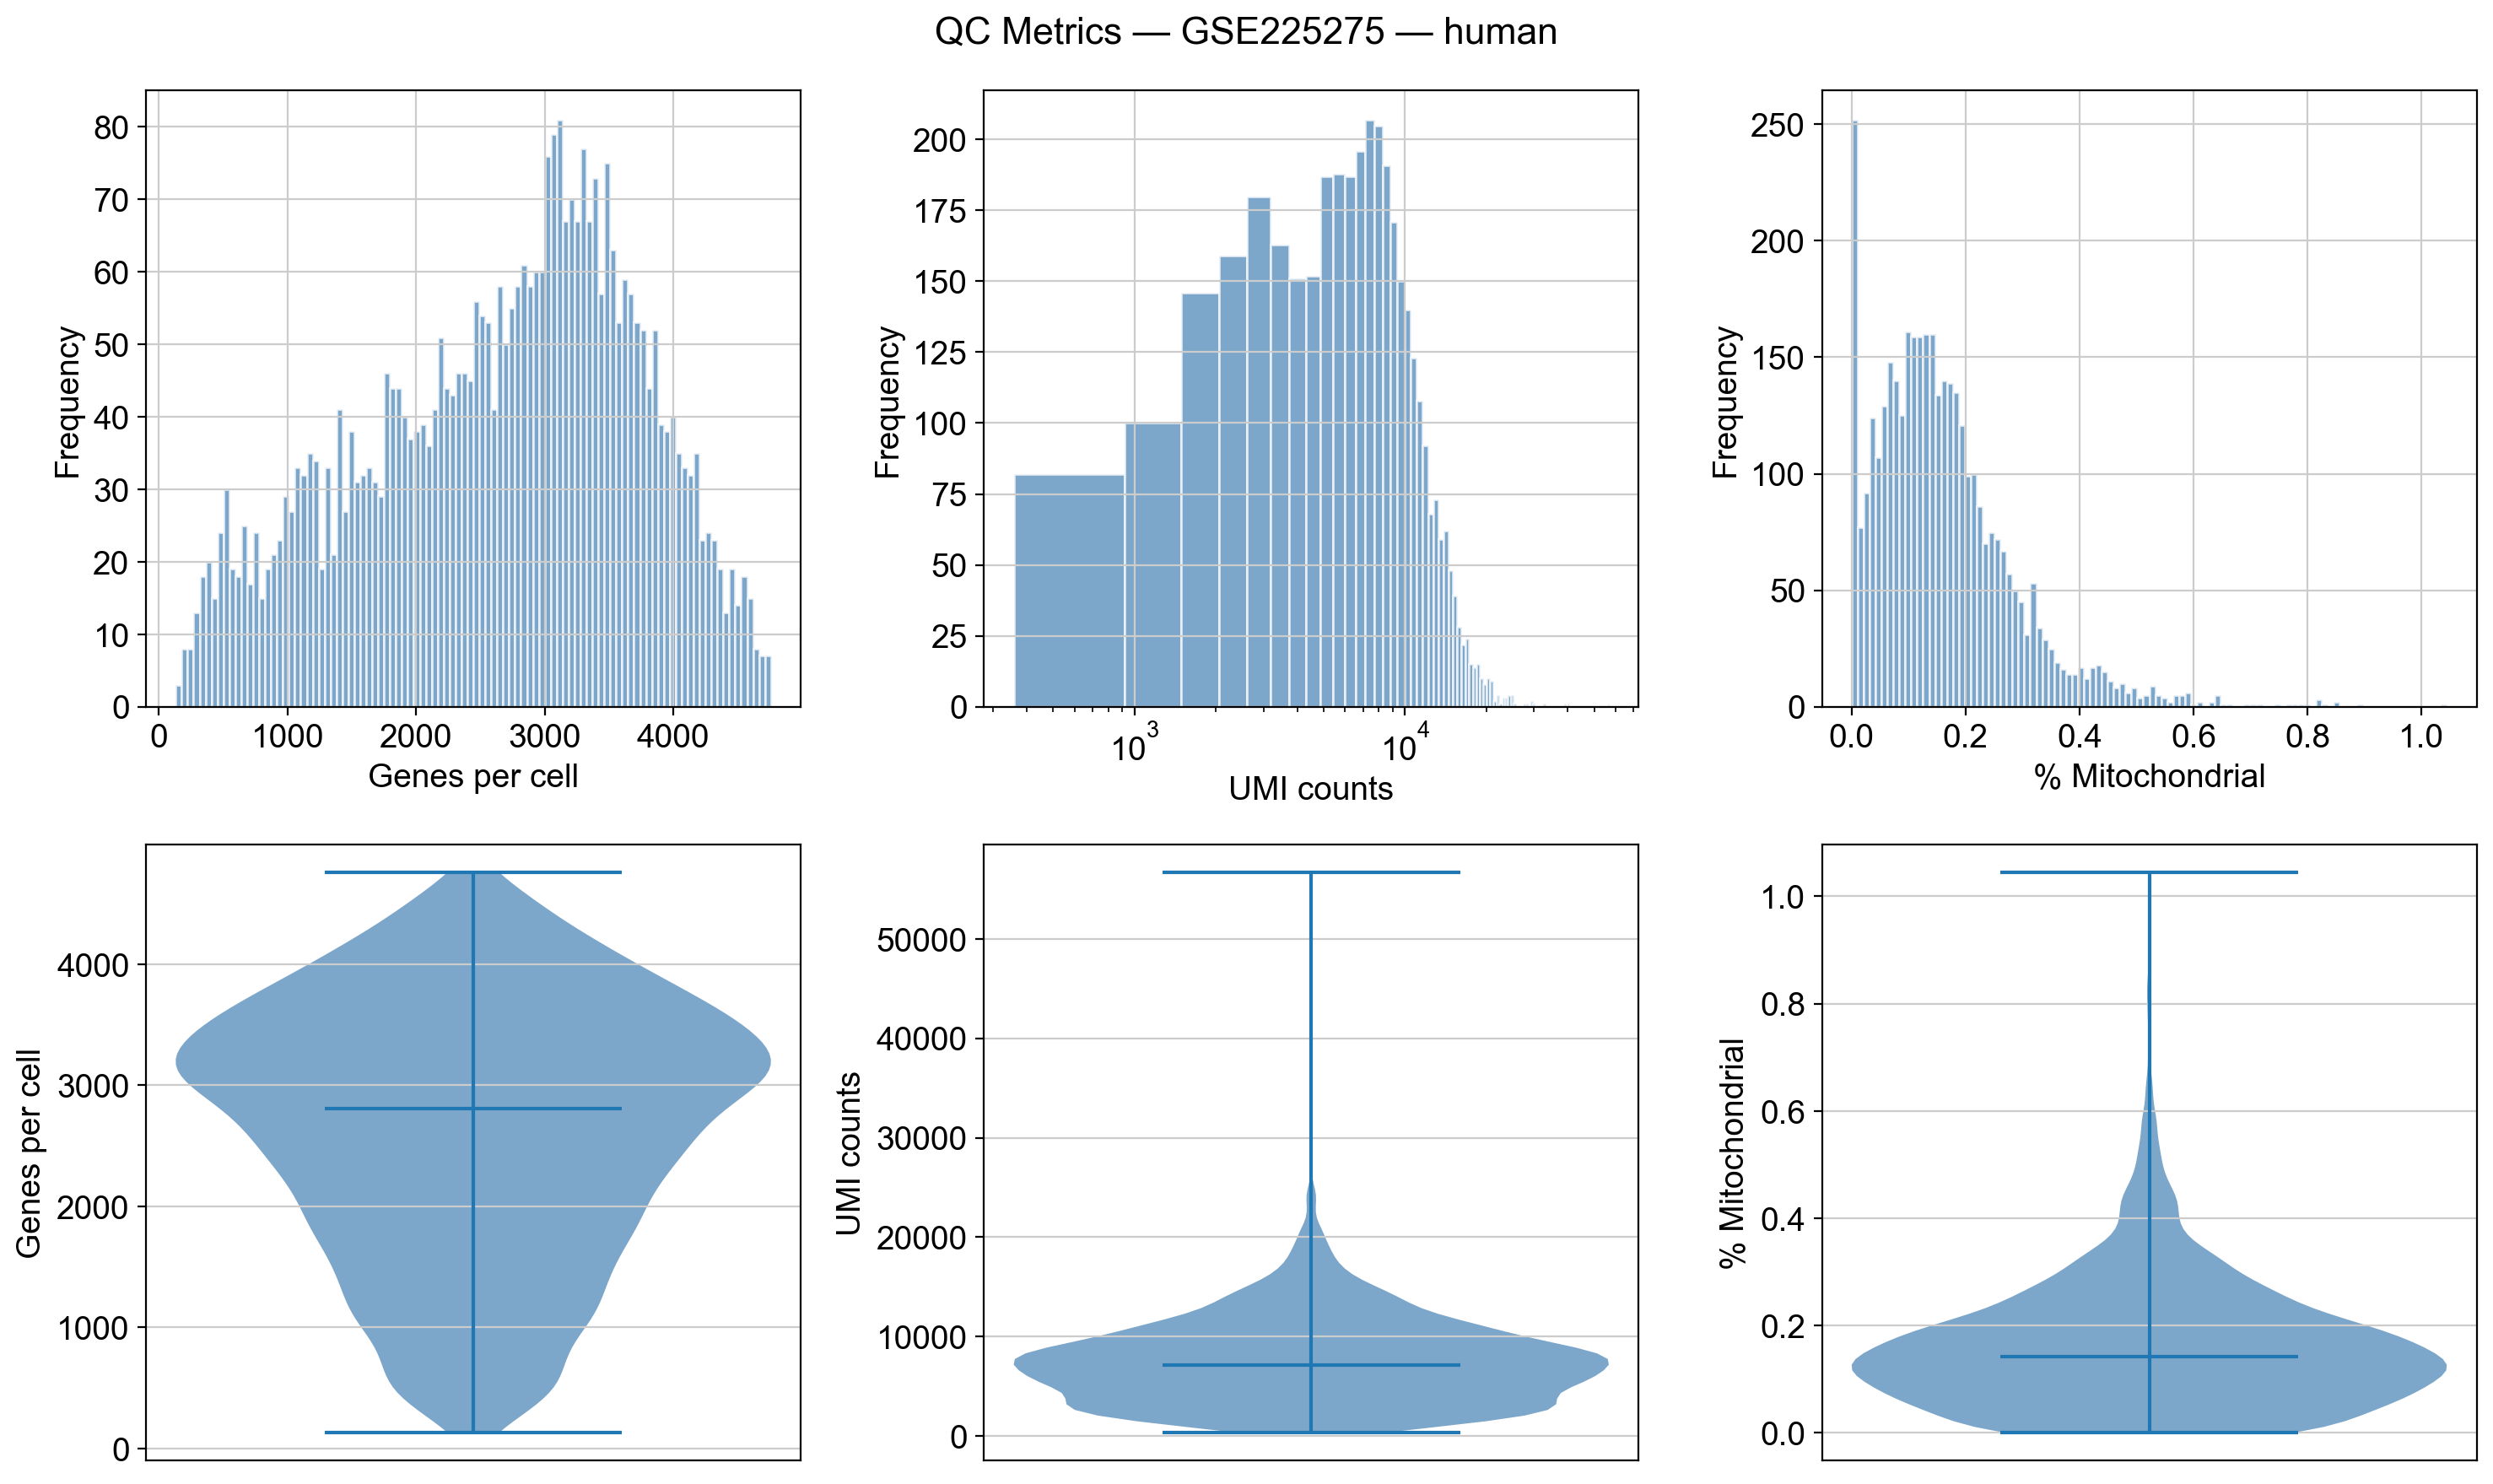

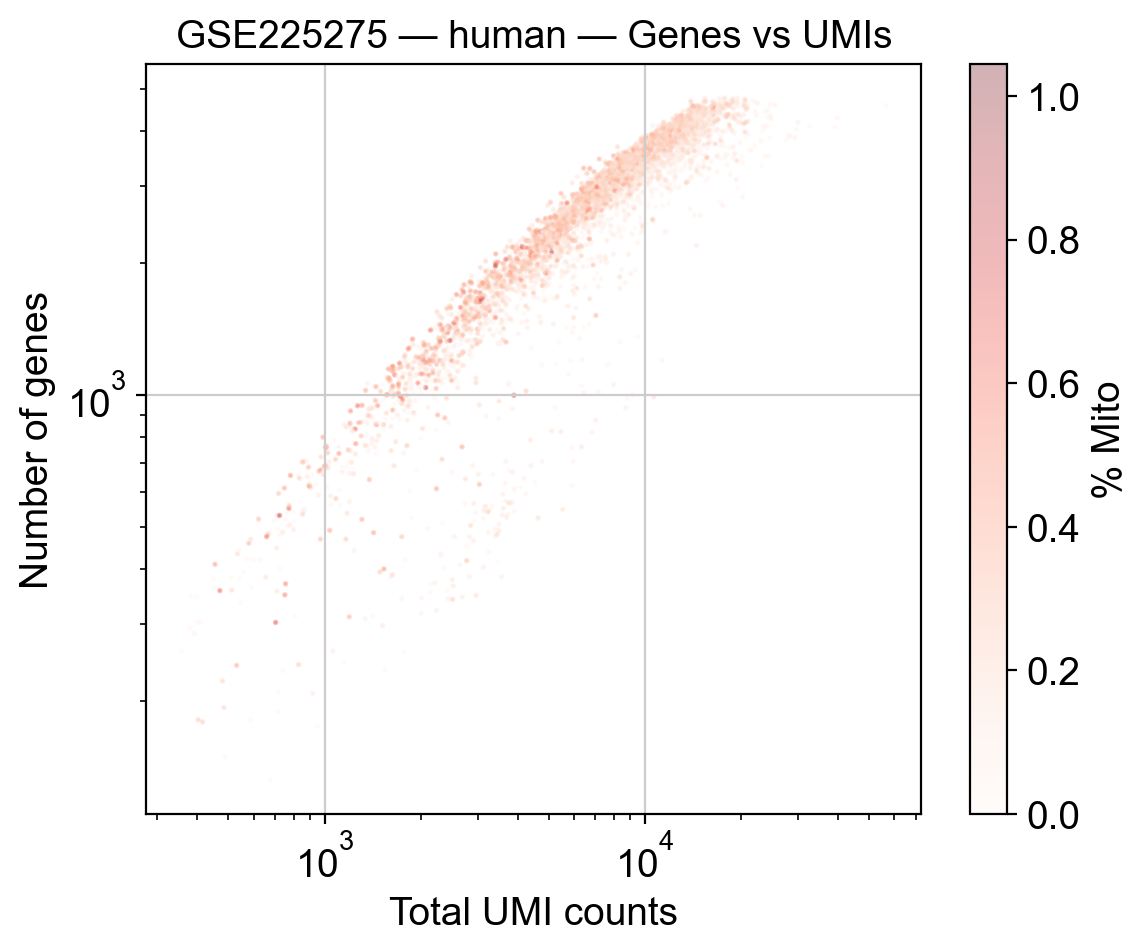


GSE225275 — human Summary:
        n_genes_by_counts  total_counts  percent_mito
count             3813.00       3813.00       3813.00
mean              2645.26       7589.24          0.16
median            2811.00       7155.00          0.14
std               1068.40       4545.79          0.12
min                132.00        357.00          0.00
max               4759.00      56672.00          1.04

--- Stage 1: Threshold Filtering ---
Stage 1 Thresholds:
  Min genes: 200, Min UMIs: 500
  Max mito %: 20%
  Max HB %: 5%
filtered out 8 cells that have less than 200 genes expressed


filtered out 14 cells that have less than 500 counts



Stage 1 Results:
  Cells before: 3813
  Cells after: 3791
  Removed: 22 (0.6%)

--- Stage 2: MAD Outlier Filtering ---
Outlier Detection:
  low_genes: 0 cells (0.0%)
  low_counts: 29 cells (0.8%)

Stage 2 Results:
  Cells before: 3791
  Cells after: 3762
  Removed: 29 (0.8%)

--- Doublet Detection ---
Running Scrublet (expected rate: 6.0%)


Preprocessing...


Simulating doublets...


Embedding transcriptomes using PCA...


Calculating doublet scores...


Automatically set threshold at doublet score = 0.55
Detected doublet rate = 0.0%
Estimated detectable doublet fraction = 2.1%
Overall doublet rate:
	Expected   = 6.0%
	Estimated  = 1.2%
Elapsed time: 9.9 seconds
Auto-detected threshold: 0.550
Predicted doublets: 1 (0.0%)


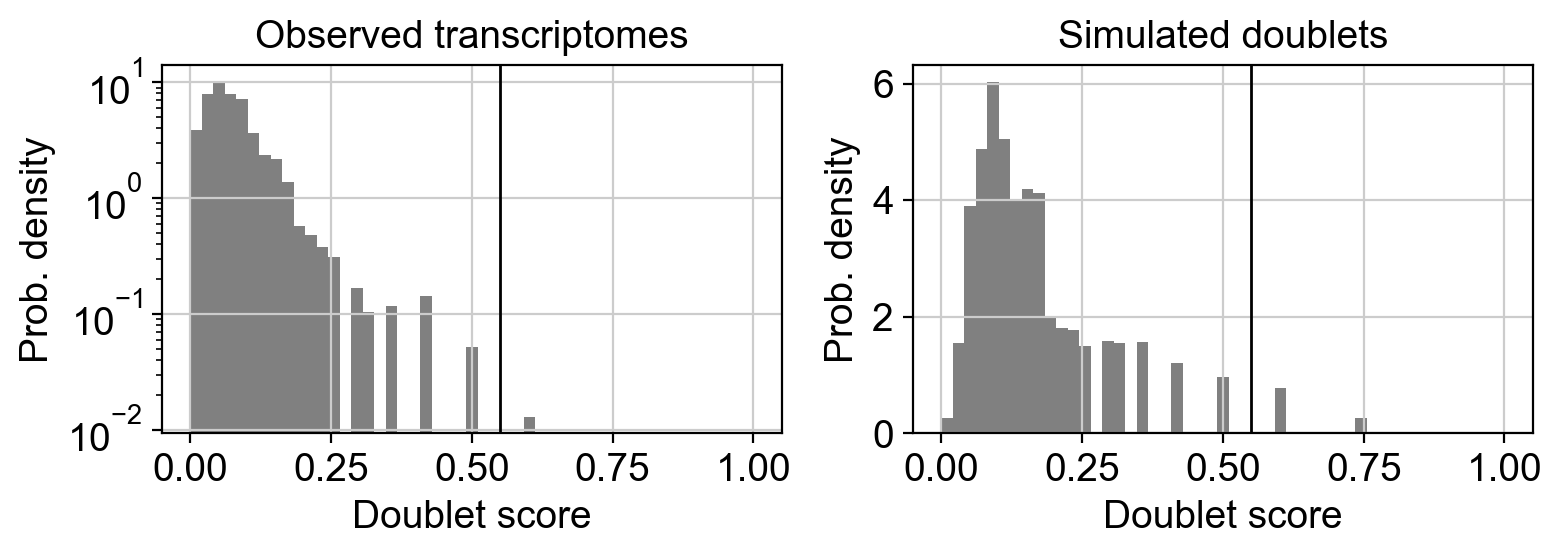

Removed 1 doublets, kept 3761 singlets

--- Gene Filtering ---
filtered out 1923 genes that are detected in less than 3 cells


Genes: 14330 -> 12407

######################################################################
# PROCESSING: MOUSE
######################################################################



--- QC Metrics ---


  Mitochondrial genes: 1
  Ribosomal genes: 49
  Hemoglobin genes: 3


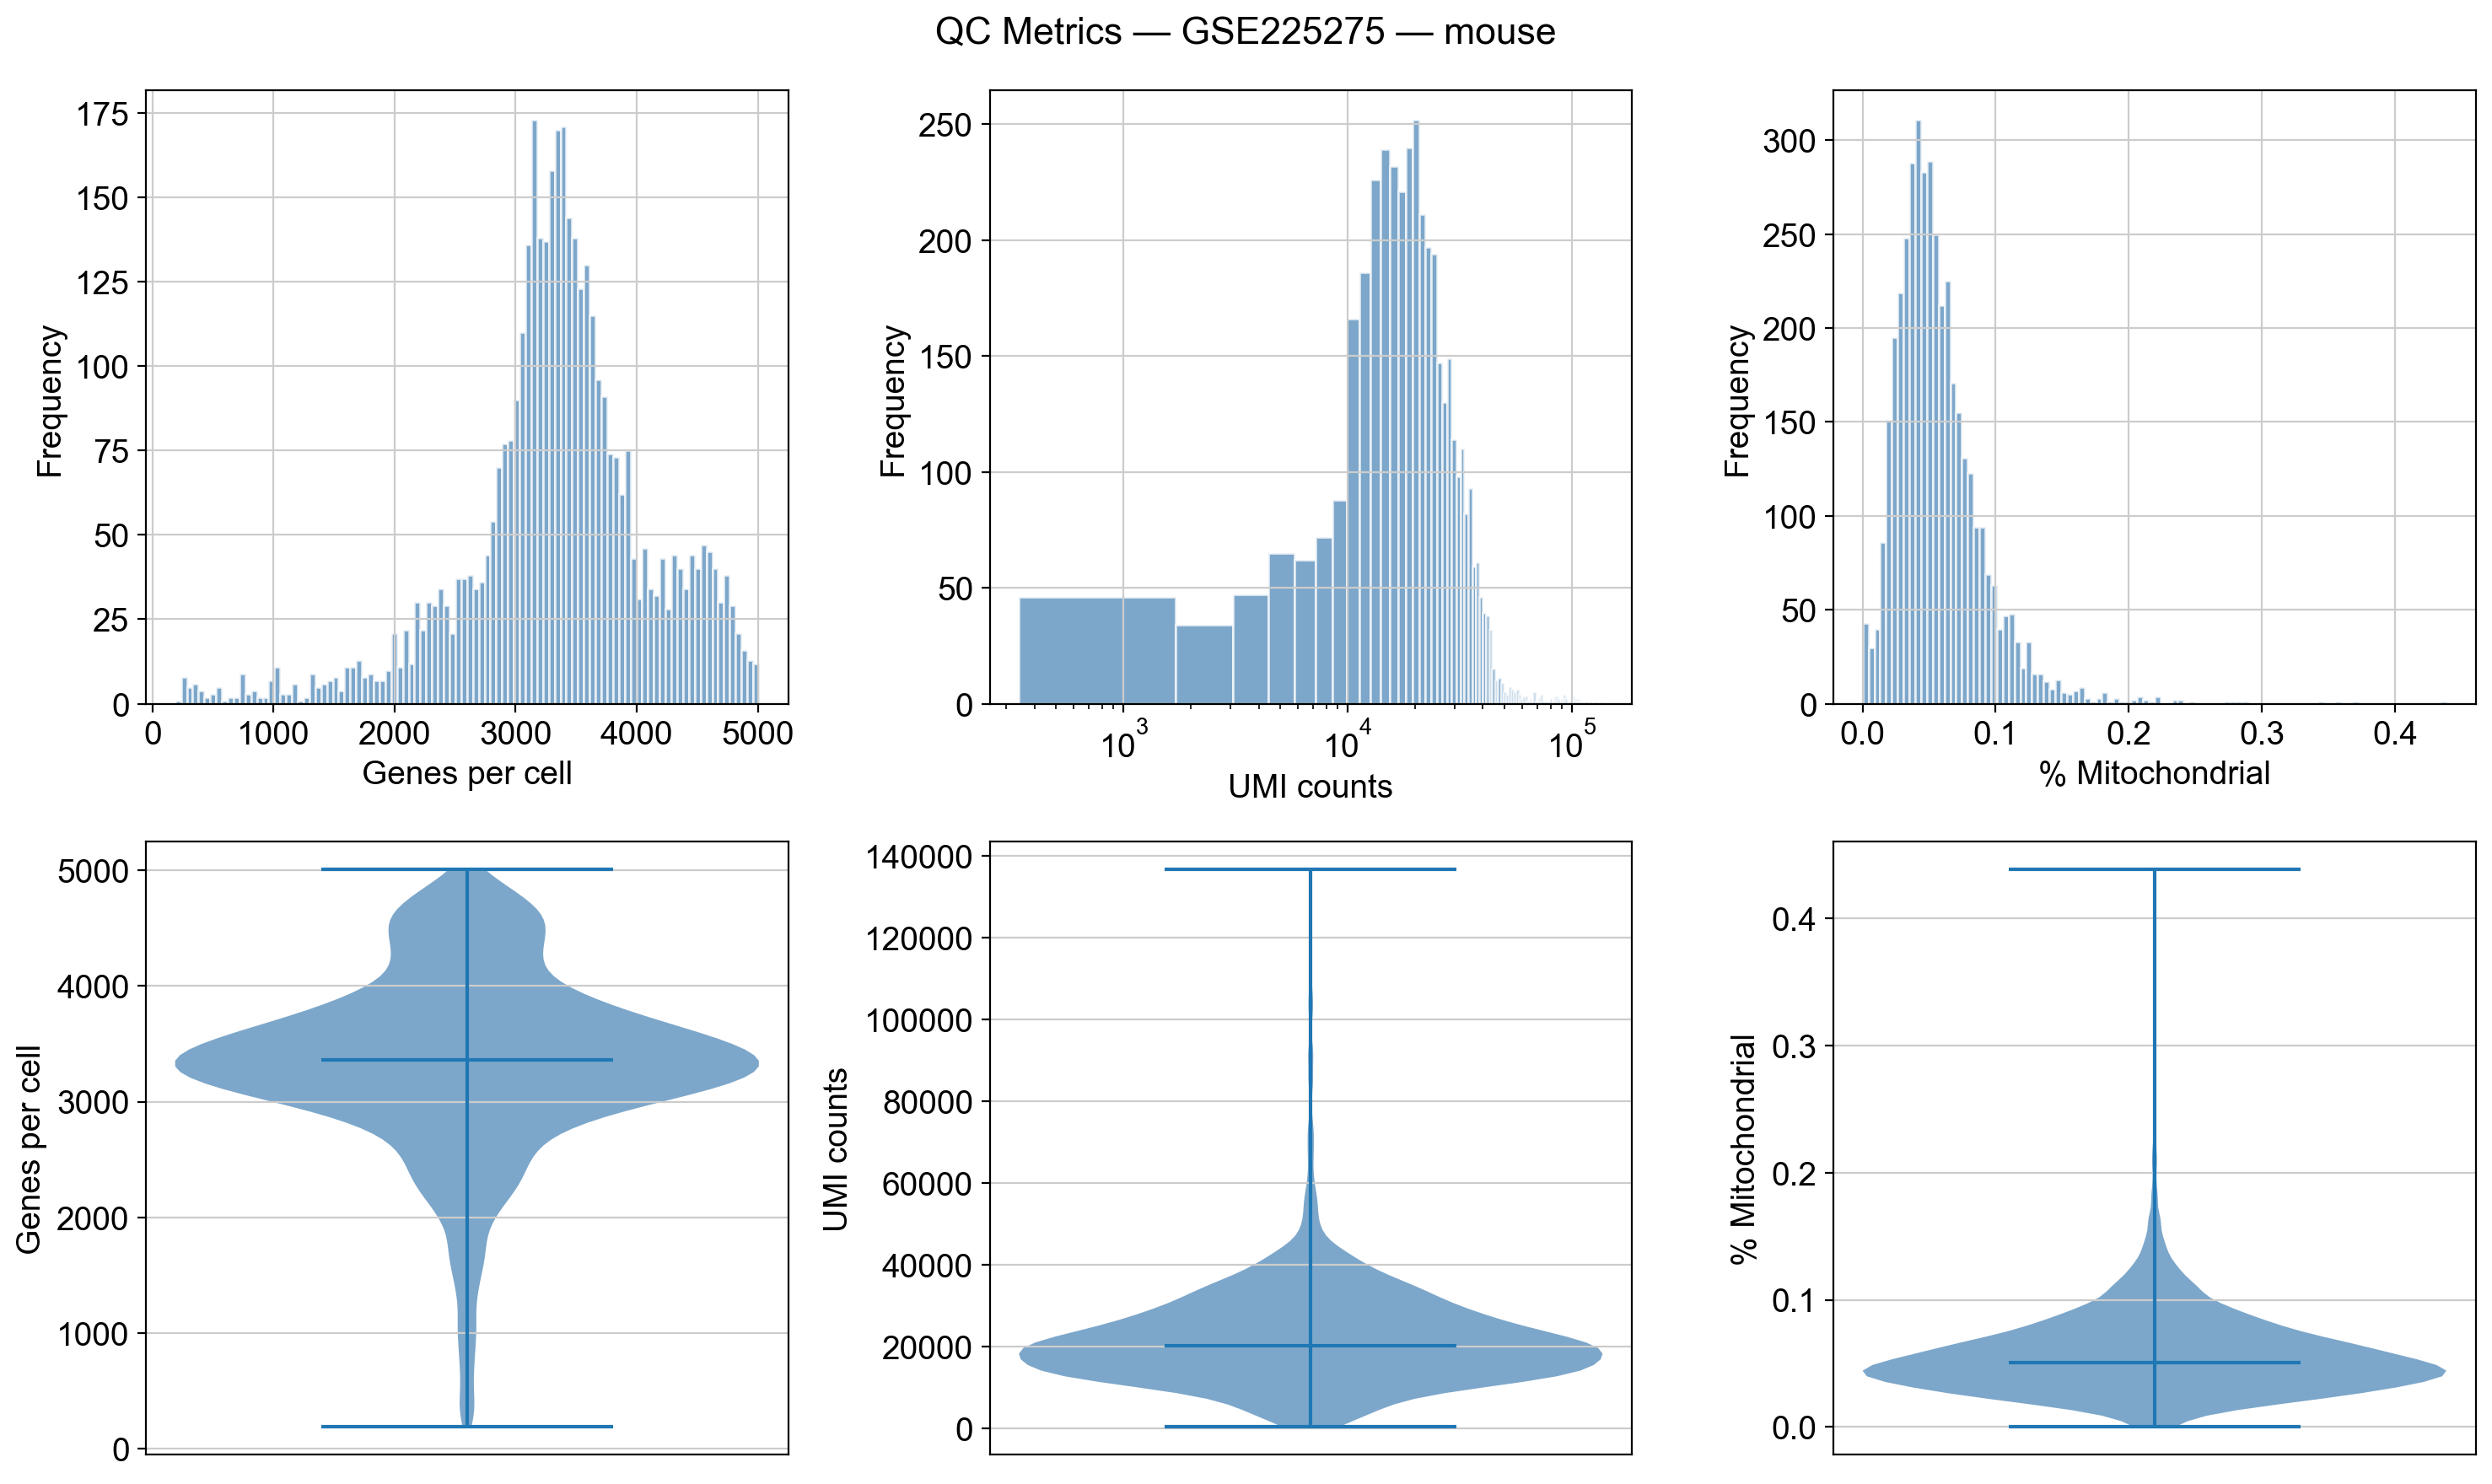

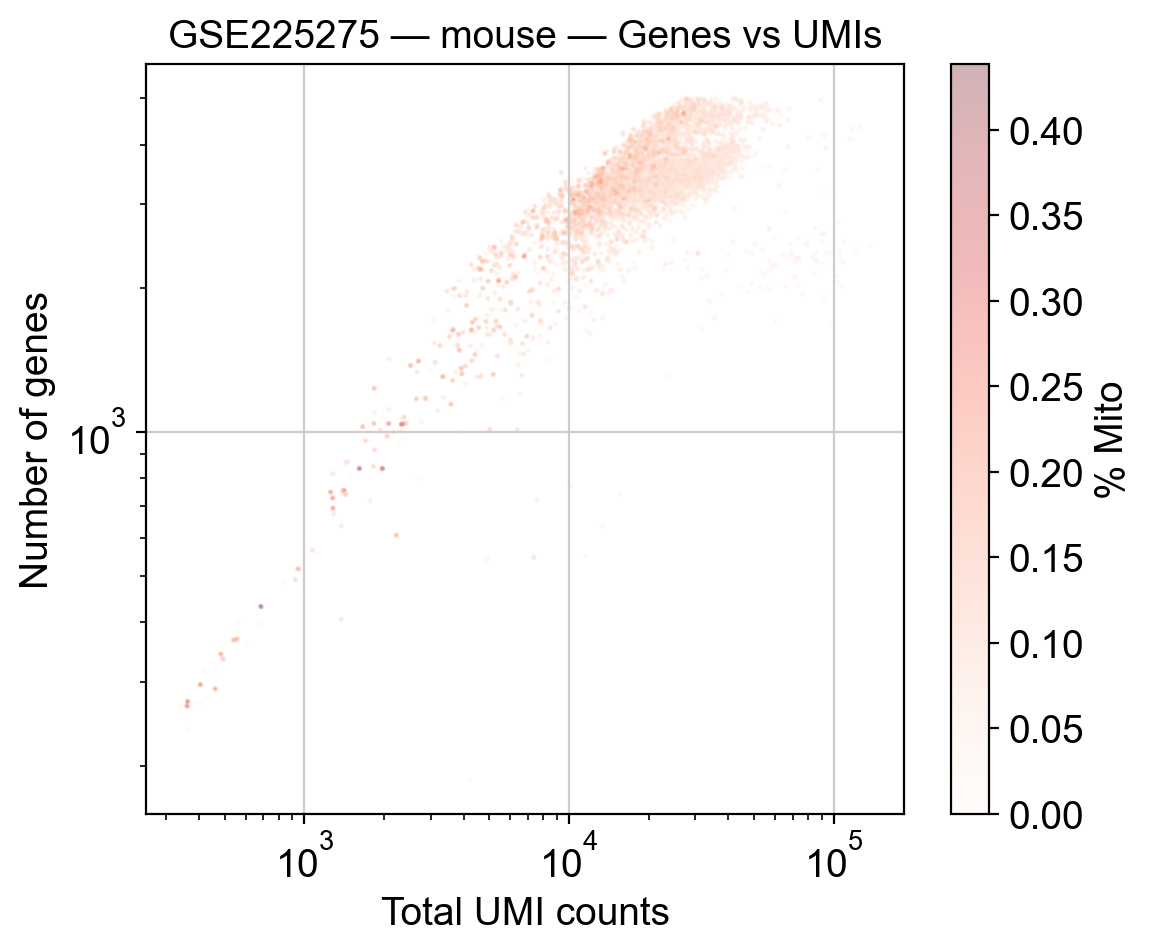


GSE225275 — mouse Summary:
        n_genes_by_counts  total_counts  percent_mito
count             4127.00       4127.00       4127.00
mean              3340.37      22286.05          0.06
median            3363.00      20181.00          0.05
std                784.70      13128.24          0.03
min                187.00        341.00          0.00
max               5009.00     136642.00          0.44

--- Stage 1: Threshold Filtering ---
Stage 1 Thresholds:
  Min genes: 200, Min UMIs: 500
  Max mito %: 20%
  Max HB %: 5%
filtered out 1 cells that have less than 200 genes expressed


filtered out 16 cells that have less than 500 counts



Stage 1 Results:
  Cells before: 4127
  Cells after: 4110
  Removed: 17 (0.4%)

--- Stage 2: MAD Outlier Filtering ---
Outlier Detection:
  low_genes: 108 cells (2.6%)
  low_counts: 88 cells (2.1%)

Stage 2 Results:
  Cells before: 4110
  Cells after: 3914
  Removed: 196 (4.8%)

--- Doublet Detection ---
Running Scrublet (expected rate: 6.0%)


Preprocessing...


Simulating doublets...


Embedding transcriptomes using PCA...


Calculating doublet scores...


Automatically set threshold at doublet score = 0.42
Detected doublet rate = 0.4%
Estimated detectable doublet fraction = 11.4%
Overall doublet rate:
	Expected   = 6.0%
	Estimated  = 3.8%
Elapsed time: 9.0 seconds
Auto-detected threshold: 0.421
Predicted doublets: 17 (0.4%)


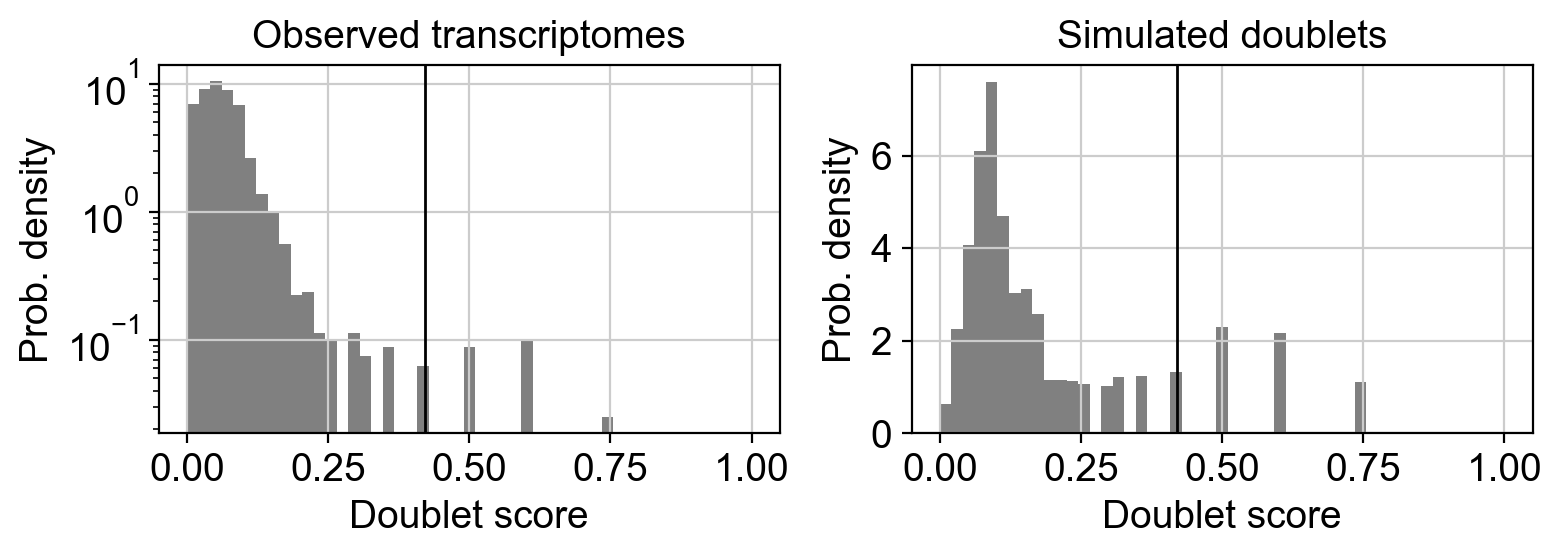

Removed 17 doublets, kept 3897 singlets

--- Gene Filtering ---
filtered out 3746 genes that are detected in less than 3 cells


Genes: 15107 -> 11361

######################################################################
# PROCESSING: RAT
######################################################################



--- QC Metrics ---
  No mt genes found — skipping


  Mitochondrial genes: 0
  Ribosomal genes: 36
  Hemoglobin genes: 3


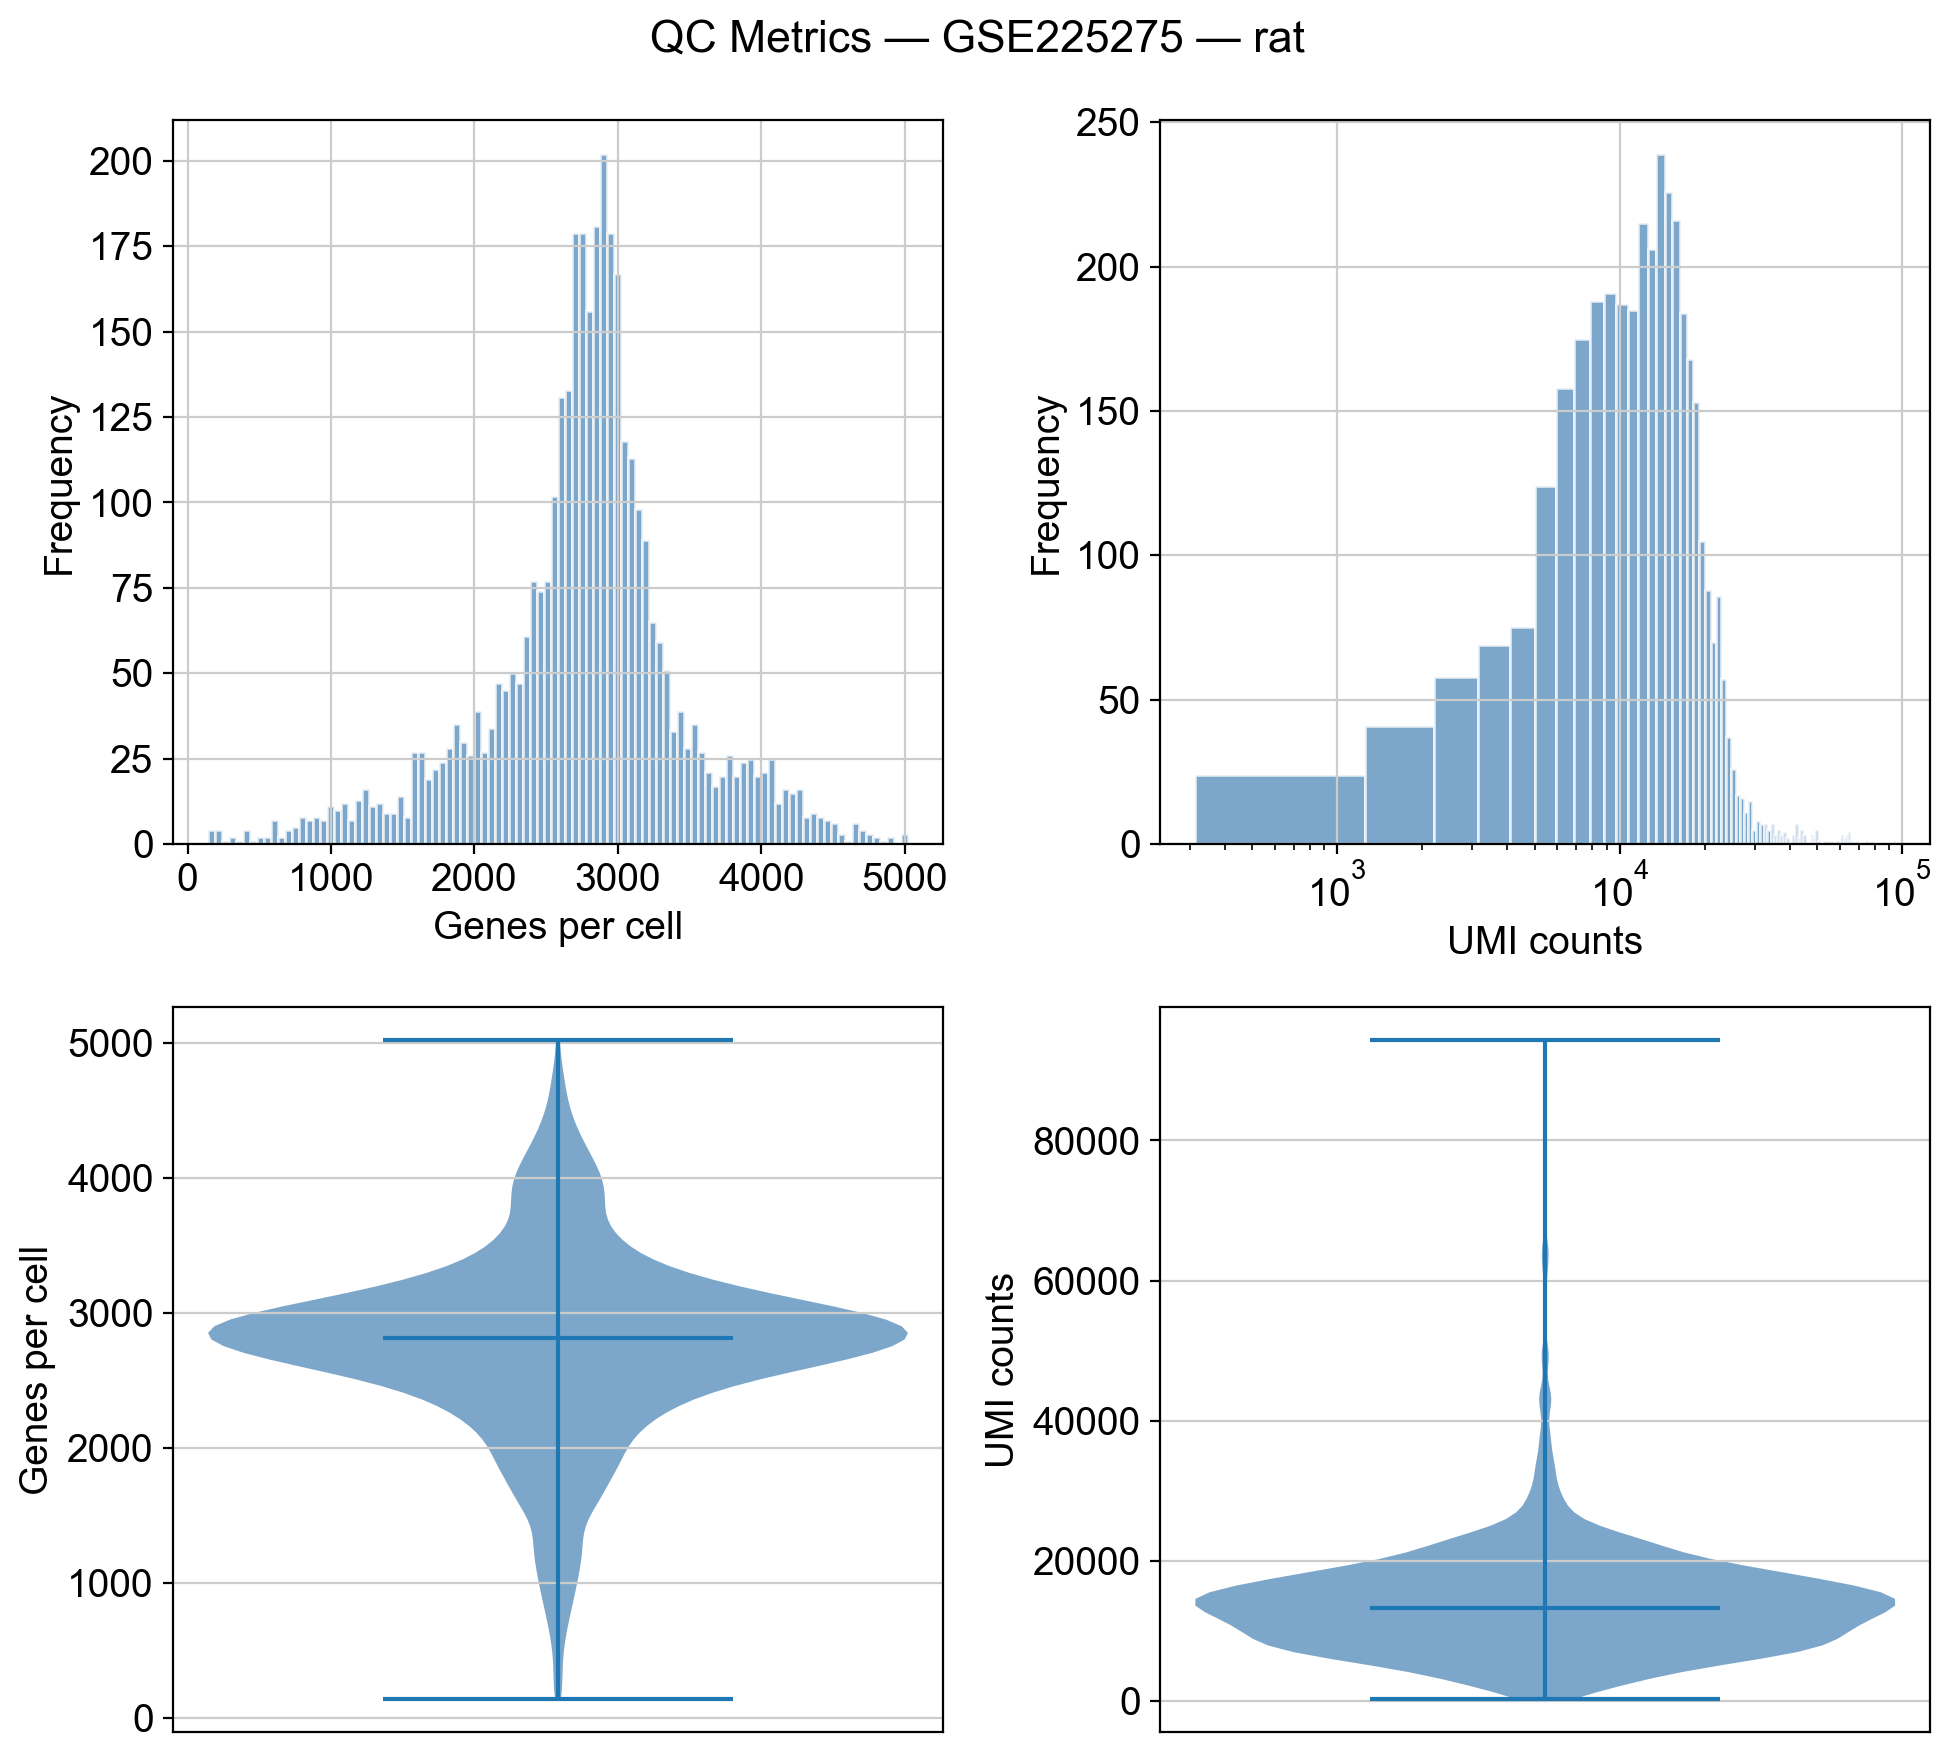

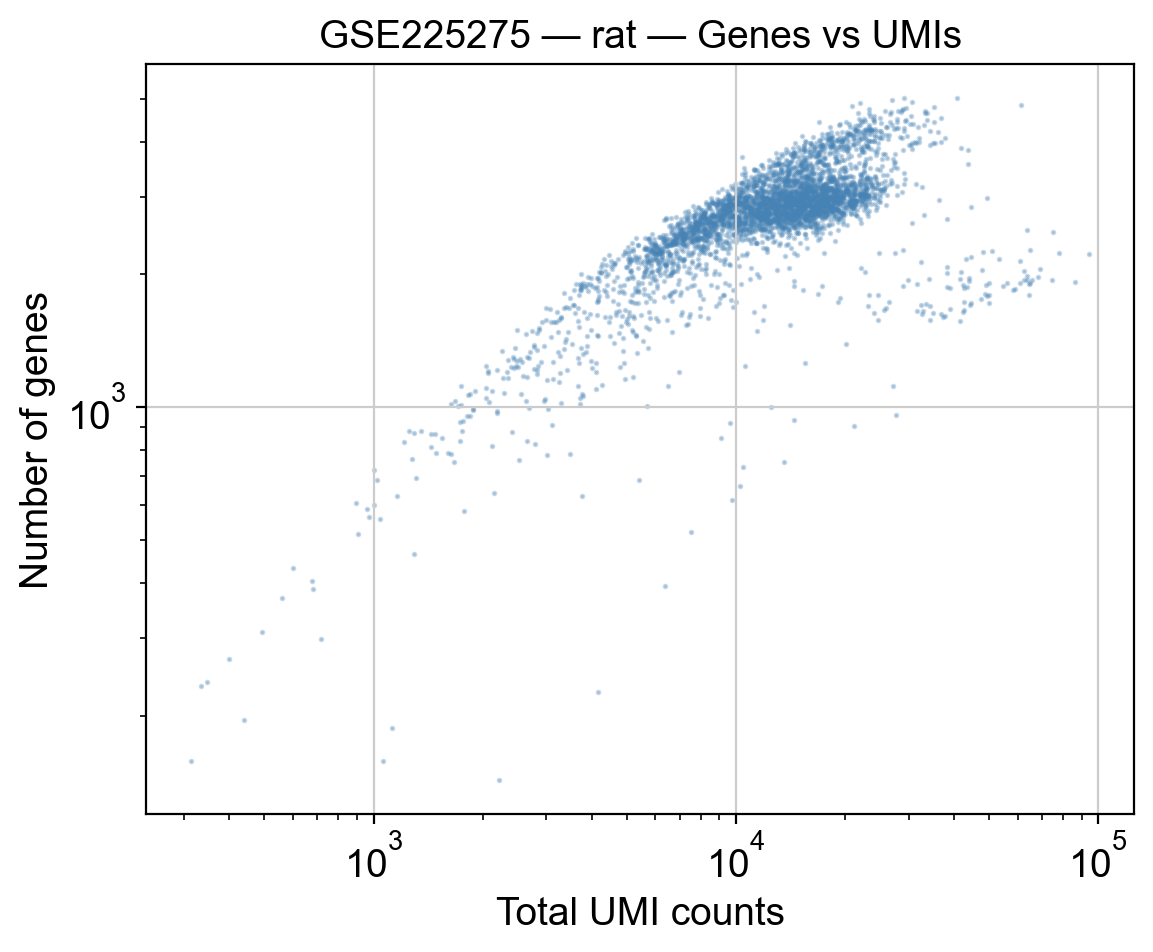


GSE225275 — rat Summary:
        n_genes_by_counts  total_counts
count             3722.00       3722.00
mean              2764.57      14001.87
median            2816.00      13326.50
std                690.83       8086.62
min                143.00        314.00
max               5021.00      94317.00

--- Stage 1: Threshold Filtering ---
Stage 1 Thresholds:
  Min genes: 200, Min UMIs: 500
  Max mito %: SKIPPED (0-1 mito genes)
  Max HB %: 5%
filtered out 5 cells that have less than 200 genes expressed


filtered out 4 cells that have less than 500 counts



Stage 1 Results:
  Cells before: 3722
  Cells after: 3713
  Removed: 9 (0.2%)

--- Stage 2: MAD Outlier Filtering ---
Outlier Detection:
  low_genes: 208 cells (5.6%)
  low_counts: 75 cells (2.0%)



Stage 2 Results:
  Cells before: 3713
  Cells after: 3435
  Removed: 278 (7.5%)

--- Doublet Detection ---
Running Scrublet (expected rate: 6.0%)


Preprocessing...


Simulating doublets...


Embedding transcriptomes using PCA...


Calculating doublet scores...


Automatically set threshold at doublet score = 0.54
Detected doublet rate = 0.2%
Estimated detectable doublet fraction = 4.2%
Overall doublet rate:
	Expected   = 6.0%
	Estimated  = 5.5%
Elapsed time: 4.8 seconds
Auto-detected threshold: 0.539
Predicted doublets: 8 (0.2%)


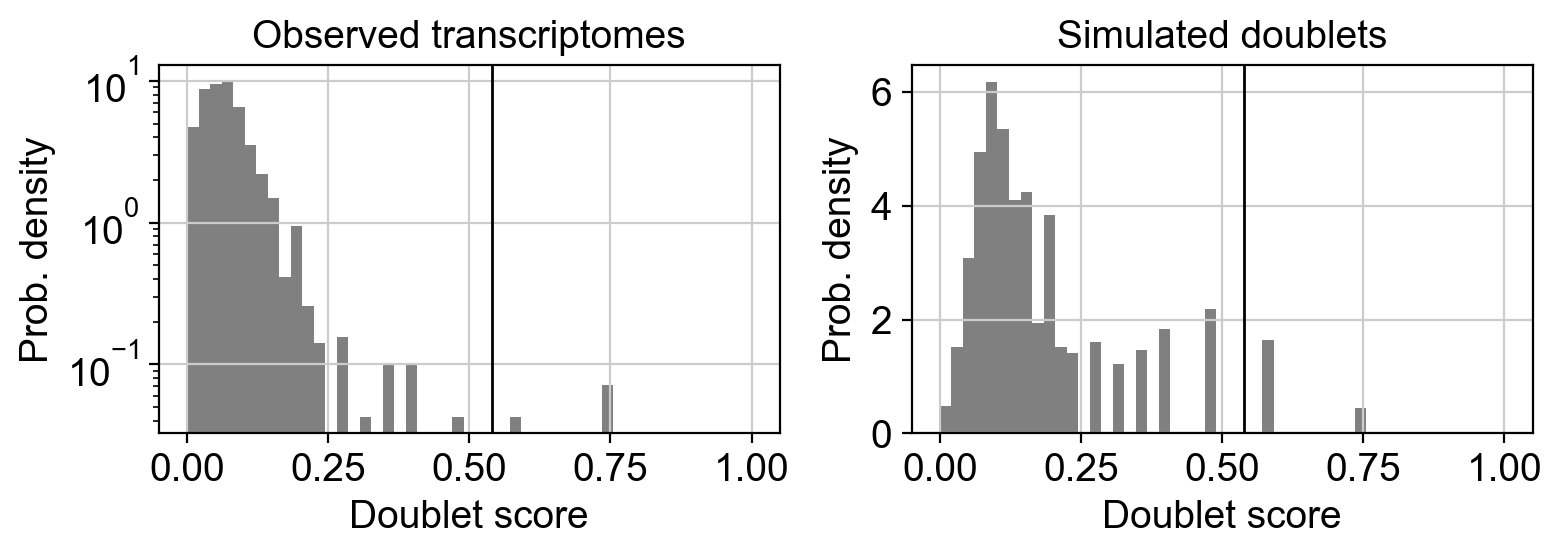

Removed 8 doublets, kept 3427 singlets

--- Gene Filtering ---
filtered out 4222 genes that are detected in less than 3 cells


Genes: 15396 -> 11174


In [9]:
# QC thresholds
MIN_GENES = 200
MIN_COUNTS = 500
MAX_GENES = None
MAX_MITO = 20
MAX_HB = 5

adatas_filtered = {}

for species in SPECIES_LIST:
    print(f"\n{'#'*70}")
    print(f"# PROCESSING: {species.upper()}")
    print(f"{'#'*70}")

    adata = adatas_raw[species].copy()

    # --- QC metrics ---
    print(f"\n--- QC Metrics ---")
    adata = calculate_qc_metrics(adata, species=species)

    # --- Visualization ---
    plot_qc_metrics(adata, f"{DATASET_ID} — {species}")

    # --- Stage 1 ---
    print(f"\n--- Stage 1: Threshold Filtering ---")
    # For mouse/rat with 0-1 mito genes, mito filtering has minimal effect
    adata = apply_stage1_filtering(
        adata,
        min_genes=MIN_GENES, min_counts=MIN_COUNTS,
        max_genes=MAX_GENES, max_mito=MAX_MITO, max_hb=MAX_HB
    )

    # --- Stage 2 ---
    print(f"\n--- Stage 2: MAD Outlier Filtering ---")
    adata = apply_stage2_filtering(adata, n_mads=5)

    # --- Doublet detection ---
    print(f"\n--- Doublet Detection ---")
    if adata.n_obs < 50:
        print(f"Skipping — only {adata.n_obs} cells")
        adata.obs['doublet_score'] = 0.0
        adata.obs['predicted_doublet'] = False
    else:
        adata = detect_doublets_scrublet(adata, expected_doublet_rate=0.06)

    # Remove doublets
    n_before = adata.n_obs
    adata = adata[~adata.obs['predicted_doublet']].copy()
    print(f"Removed {n_before - adata.n_obs} doublets, kept {adata.n_obs} singlets")

    # --- Filter genes ---
    print(f"\n--- Gene Filtering ---")
    n_genes_before = adata.n_vars
    sc.pp.filter_genes(adata, min_cells=3)
    print(f"Genes: {n_genes_before} -> {adata.n_vars}")

    adatas_filtered[species] = adata

## 4. Before vs After Comparison

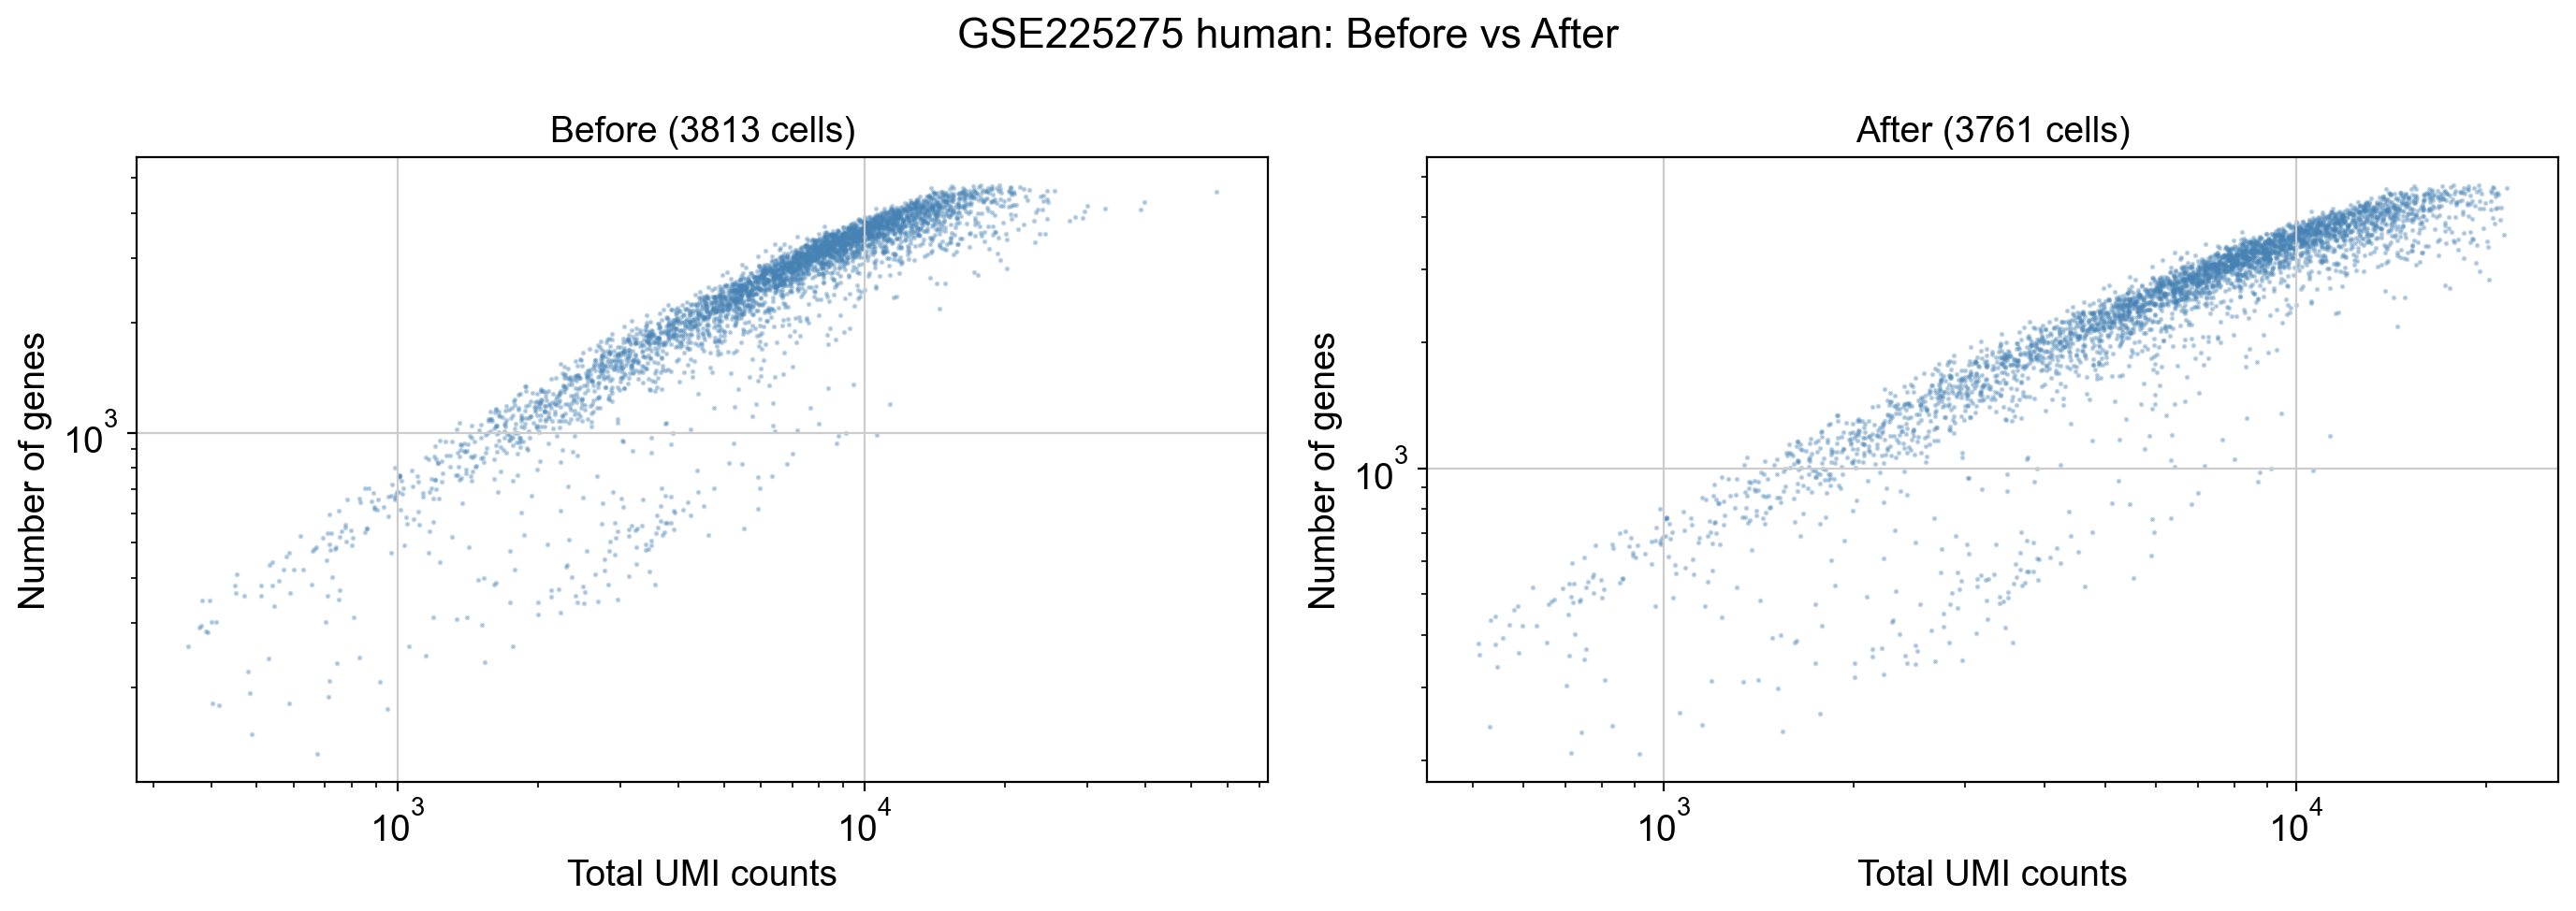

human: Removed 52 cells (1.4%)



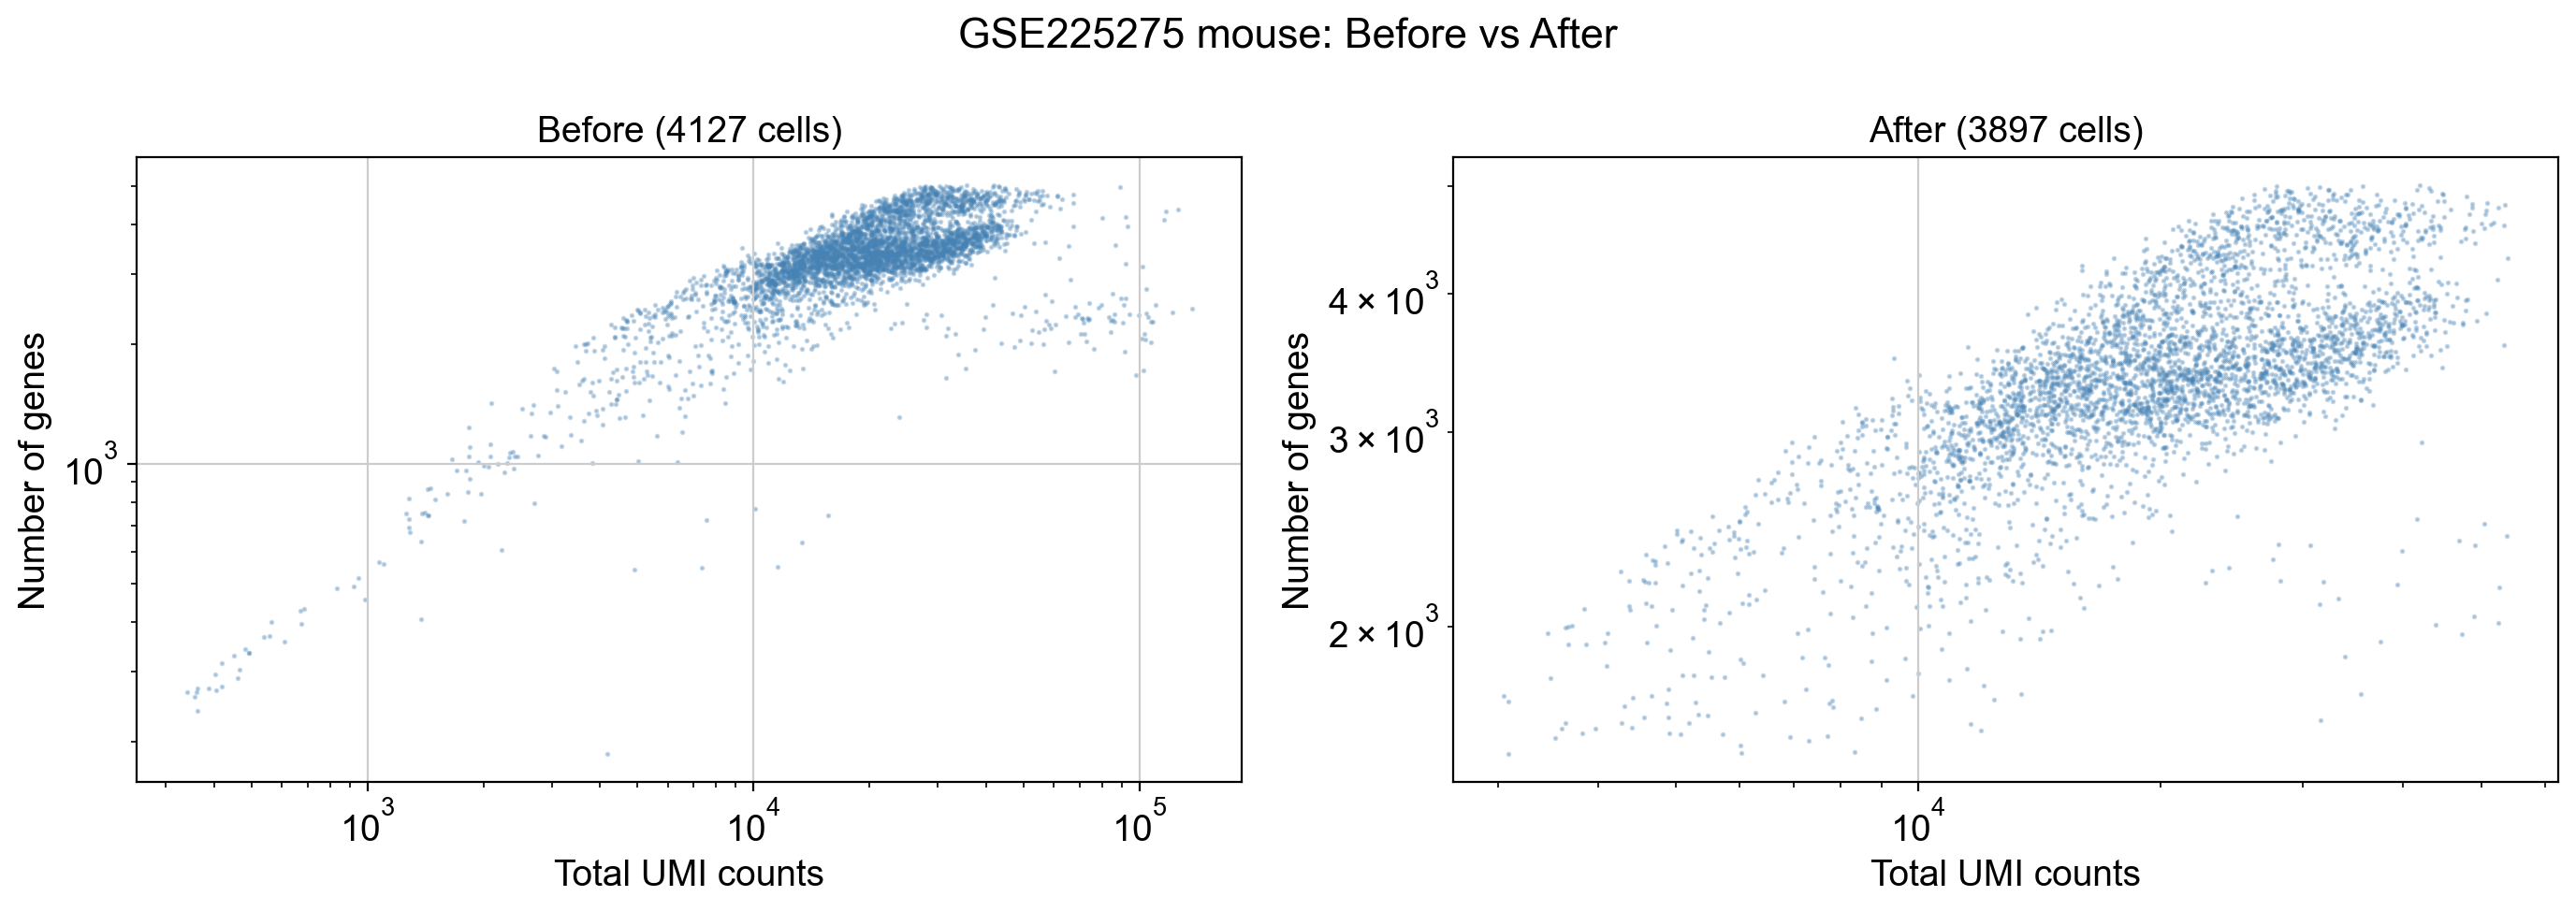

mouse: Removed 230 cells (5.6%)



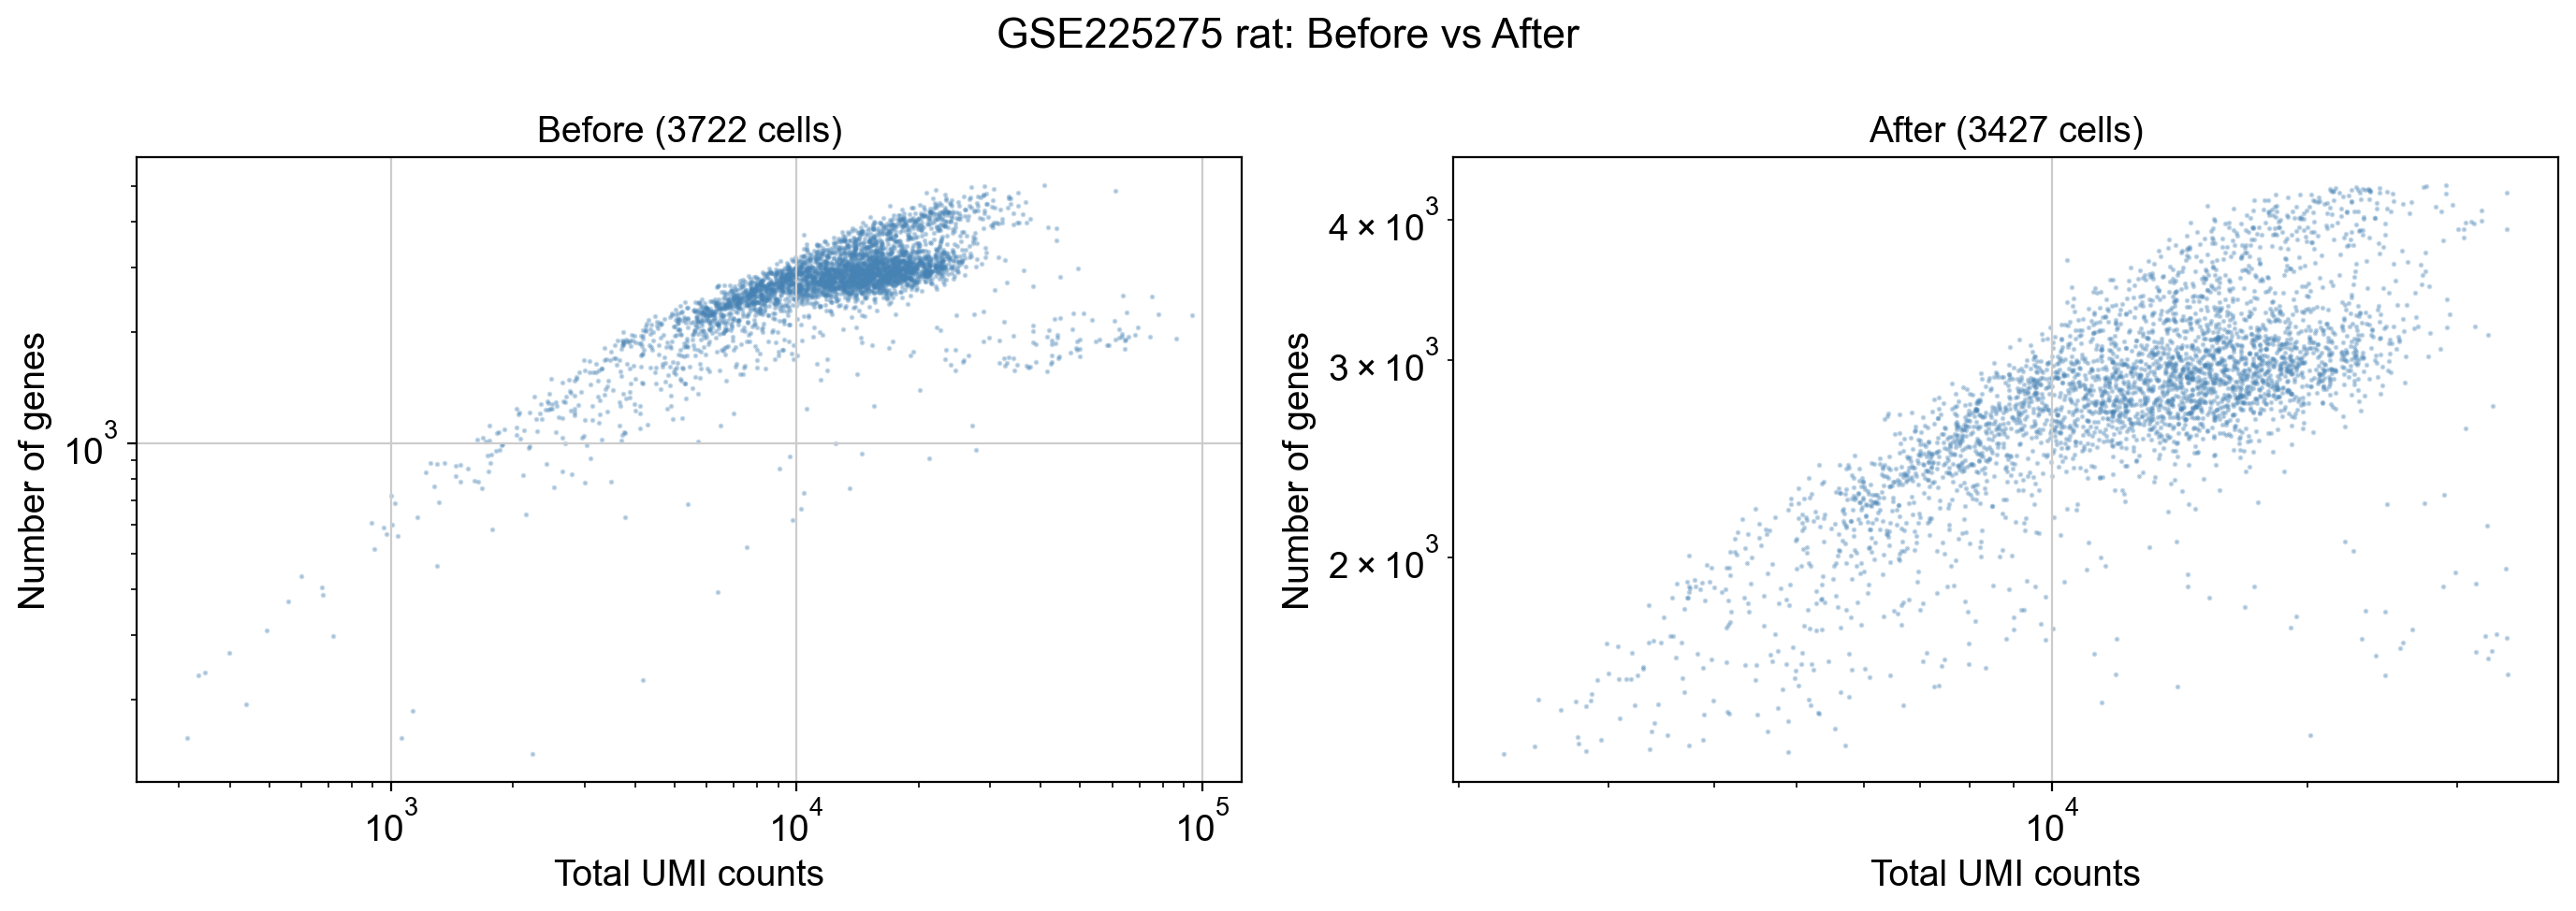

rat: Removed 295 cells (7.9%)



In [10]:
for species in SPECIES_LIST:
    adata_before = adatas_raw[species]
    adata_after = adatas_filtered[species]

    has_mito = 'percent_mito' in adata_before.obs.columns and adata_before.obs['percent_mito'].sum() > 0

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'{DATASET_ID} {species}: Before vs After', fontsize=16)

    c_before = adata_before.obs['percent_mito'] if has_mito else 'steelblue'
    c_after = adata_after.obs['percent_mito'] if has_mito else 'steelblue'
    cmap = 'Reds' if has_mito else None

    axes[0].scatter(adata_before.obs['total_counts'], adata_before.obs['n_genes_by_counts'],
                    c=c_before, alpha=0.3, s=1, cmap=cmap)
    axes[0].set_xlabel('Total UMI counts'); axes[0].set_ylabel('Number of genes')
    axes[0].set_title(f'Before ({adata_before.n_obs} cells)')
    axes[0].set_xscale('log'); axes[0].set_yscale('log')

    im = axes[1].scatter(adata_after.obs['total_counts'], adata_after.obs['n_genes_by_counts'],
                         c=c_after, alpha=0.3, s=1, cmap=cmap)
    axes[1].set_xlabel('Total UMI counts'); axes[1].set_ylabel('Number of genes')
    axes[1].set_title(f'After ({adata_after.n_obs} cells)')
    axes[1].set_xscale('log'); axes[1].set_yscale('log')

    if has_mito:
        plt.colorbar(im, ax=axes[1], label='% Mitochondrial')

    plt.tight_layout(); plt.show()

    n_removed = adata_before.n_obs - adata_after.n_obs
    pct_removed = (n_removed / adata_before.n_obs) * 100 if adata_before.n_obs > 0 else 0
    print(f"{species}: Removed {n_removed} cells ({pct_removed:.1f}%)\n")

## 5. Save Filtered Data

One filtered h5ad file per species.

In [11]:
os.makedirs(OUTPUT_DIR, exist_ok=True)

for species, adata in adatas_filtered.items():
    output_file = f'{OUTPUT_DIR}/{DATASET_ID}_{species}_filtered.h5ad'
    adata.write_h5ad(output_file)
    print(f"Saved: {output_file}")
    print(f"  {adata.n_obs} cells x {adata.n_vars} genes")

Saved: ../data/processed/GSE225275_human_filtered.h5ad
  3761 cells x 12407 genes


Saved: ../data/processed/GSE225275_mouse_filtered.h5ad
  3897 cells x 11361 genes


Saved: ../data/processed/GSE225275_rat_filtered.h5ad
  3427 cells x 11174 genes


## 6. Summary Report

In [12]:
print("="*60)
print("QC FILTERING SUMMARY — GSE225275")
print("="*60)

for species in SPECIES_LIST:
    raw = adatas_raw[species]
    filt = adatas_filtered[species]
    pct = (filt.n_obs / raw.n_obs) * 100 if raw.n_obs > 0 else 0

    print(f"\n--- {species} ---")
    print(f"  Raw: {raw.n_obs} cells x {raw.n_vars} genes")
    print(f"  Filtered: {filt.n_obs} cells x {filt.n_vars} genes")
    print(f"  Retained: {pct:.1f}%")
    print(f"  Median genes/cell: {filt.obs['n_genes_by_counts'].median():.0f}")
    print(f"  Median UMIs/cell: {filt.obs['total_counts'].median():.0f}")
    if 'percent_mito' in filt.obs.columns:
        print(f"  Median mito %: {filt.obs['percent_mito'].median():.2f}%")
    print(f"  Output: {OUTPUT_DIR}/{DATASET_ID}_{species}_filtered.h5ad")

total_raw = sum(a.n_obs for a in adatas_raw.values())
total_filt = sum(a.n_obs for a in adatas_filtered.values())
print(f"\nTotal across all species: {total_raw} -> {total_filt} cells ({total_filt/total_raw*100:.1f}% retained)")

QC FILTERING SUMMARY — GSE225275

--- human ---
  Raw: 3813 cells x 14330 genes
  Filtered: 3761 cells x 12407 genes
  Retained: 98.6%
  Median genes/cell: 2808
  Median UMIs/cell: 7146
  Median mito %: 0.14%
  Output: ../data/processed/GSE225275_human_filtered.h5ad

--- mouse ---
  Raw: 4127 cells x 15107 genes
  Filtered: 3897 cells x 11361 genes
  Retained: 94.4%
  Median genes/cell: 3383
  Median UMIs/cell: 20228
  Median mito %: 0.05%
  Output: ../data/processed/GSE225275_mouse_filtered.h5ad

--- rat ---
  Raw: 3722 cells x 15396 genes
  Filtered: 3427 cells x 11174 genes
  Retained: 92.1%
  Median genes/cell: 2833
  Median UMIs/cell: 13332
  Median mito %: 0.00%
  Output: ../data/processed/GSE225275_rat_filtered.h5ad

Total across all species: 11662 -> 11085 cells (95.1% retained)
